# DC-Corrected Data Inspection

The raw real-part visibility has a slowly-varying DC pedestal. Several
mechanisms can contribute, and the rolling-median approach handles all of
them empirically without having to commit to any one model:

- **System-temperature drift with elevation.** The total power on each antenna
  scales as $T_{\mathrm{sys}}(\mathrm{el})$, which rises near the horizon as
  the antenna sees more warm ground (standard antenna-temperature treatment,
  [R&W] §4 / [TMS3] §6.2).
- **Direct solar coupling and ground spillover** as the Sun moves across
  the sky, changing the side-lobe response of each dish.
- **Slow gain drift** in the front-end LNAs and the IF chain with
  temperature.
- **DC offsets in the back-end** (ADC bias, FPGA pipeline) that may step
  between observing chips.

We remove the pedestal with an **adaptive rolling median** whose window
width scales with the local fringe period, ensuring we always average over
the same number of fringe cycles regardless of hour angle. The same
period-tracking idea underlies the standard "fringe rotation" used to keep
correlation losses small in connected-element arrays ([TMS3] §6.1.7).

## Why adaptive?

The fringe period is $P_f(h) = 1/|f_f| \propto 1/|\cos h|$: ~26 s at transit
for our 15.17 m baseline (predicted in nb 03 §3.1), stretching to 75+ s at
$h = \pm 70°$. A fixed 100 s window spans ~4 fringe cycles at transit but
only ~1.3 cycles at large HA — dangerously close to subtracting real fringe
power. An adaptive window that maintains a constant number of fringe
periods avoids this.

## Why this is *not* a free lunch

A median over $N_P$ fringe cycles of a sinusoid of unit amplitude is
**not exactly zero** unless $N_P$ is a half-integer; the residual leakage
is $\lesssim 1/N_P$ for large $N_P$. With $N_P = 3$ and a slowly-varying
$|\cos h|$ across the window, the leakage we expect to subtract from the
real part is $\sim 1\%$ of the fringe amplitude — small, but not zero, and
ultimately a systematic floor on the recovered fringe amplitude. We
quantify this with a synthetic injection test below; the injection
methodology mirrors the standard "completeness simulation" approach used
to characterise filtering bias in time-series astronomy.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    PLOT_BAND_GHZ,
    NOMINAL_B_EW_M, BAD_CHANNELS,
    load_processed_sun_chip_series,
    fringe_period_s,
    # plotting
    NEUTRAL_COLOR,
    LW_FINE, LW_LIGHT,
    TEXTWIDTH_IN, TICK_SIZE,
)

COMPONENT_COLORS = [f"C{i}" for i in range(10)]

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
# --- Load data ---
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
chip_data = load_processed_sun_chip_series(chip_paths)

captures    = chip_data.captures
corr_raw    = captures.corr
unix_mid    = captures.unix_mid
ha_deg_arr  = chip_data.ha_deg
ha_rad_arr  = np.deg2rad(ha_deg_arr)
sun_dec     = chip_data.sun_dec_deg
F_SKY_GHZ   = chip_data.f_sky_ghz
F_SKY_HZ    = F_SKY_GHZ * 1e9
chip_slices = chip_data.chip_slices
N_chips     = len(chip_slices)

dec_rad_mean   = np.deg2rad(np.nanmean(sun_dec))
band_mask      = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
for bc in BAD_CHANNELS:
    band_mask[bc] = False
band_center_hz = np.mean(F_SKY_HZ[band_mask])
bad_ch_arr     = np.array(BAD_CHANNELS, dtype=int)

CHIP_COLORS = COMPONENT_COLORS[:N_chips]
print(f"Loaded {corr_raw.shape[0]} captures, {N_chips} chips")

Loaded 8226 captures, 3 chips


## Adaptive rolling median DC correction

(The same period-tracking idea — adapting the analysis window to the instantaneous fringe period — is what connected-element correlators do as fringe rotation; see [TMS3] §6.1.7 for the production-grade version.) For each capture at hour angle $h$, the local fringe period is

$$P_f(h) = \frac{1}{|f_f(h)|} = \frac{\lambda}{\omega_\oplus\, b_{\mathrm{ew}}\,\cos\delta\,|\cos h|}.$$

We set the rolling-median window to a fixed number of fringe periods $N_P$:

$$W(h) = N_P \times P_f(h) = \frac{N_P\,\lambda}{\omega_\oplus\, b_{\mathrm{ew}}\,\cos\delta\,|\cos h|},$$

then convert to capture count via the local cadence. This guarantees the window always spans $N_P$ full fringe cycles, so the median is not biased by the fringe oscillation.

We clamp the window to $[W_{\min},\, W_{\max}]$ captures to avoid degenerate behaviour at $h \to \pm 90°$ (where $P_f \to \infty$) and to ensure enough points for a robust median.

In [3]:
from utils import adaptive_real_dc_correction

# --- Tunable parameters ---
N_PERIODS       = 3.0    # number of fringe periods per window
MIN_WINDOW_CAPS = 7      # minimum window (captures)
MAX_WINDOW_CAPS = 201    # maximum window (captures)

print(f"Adaptive DC correction parameters:")
print(f"  n_periods       = {N_PERIODS}")
print(f"  min_window_caps = {MIN_WINDOW_CAPS}")
print(f"  max_window_caps = {MAX_WINDOW_CAPS}")

Adaptive DC correction parameters:
  n_periods       = 3.0
  min_window_caps = 7
  max_window_caps = 201


In [4]:
# --- Apply adaptive DC correction per chip ---
dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=bad_ch_arr,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=N_PERIODS,
    min_window_caps=MIN_WINDOW_CAPS,
    max_window_caps=MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc
real_offset_chips = dc_result.real_offset_chips
window_caps_concat = dc_result.window_caps

for ci, wc in enumerate(dc_result.window_caps_chips):
    cad = np.median(np.diff(unix_mid[chip_slices[ci]]))
    print(f"  Chip {ci}: {len(wc)} captures, "
          f"window range {wc.min()}–{wc.max()} caps "
          f"({wc.min() * cad:.0f}–{wc.max() * cad:.0f} s)")

print(f"\nTotal DC-corrected captures: {corr_dc.shape[0]}")

  Chip 0: 5514 captures, window range 23–55 caps (61–146 s)
  Chip 1: 403 captures, window range 23–35 caps (58–88 s)
  Chip 2: 2309 captures, window range 21–39 caps (53–98 s)

Total DC-corrected captures: 8226


## Waterfall plot: visibility amplitude and phase vs HA and frequency

A 2-D view of the DC-corrected visibility across the full analysis band.
Three HA windows are shown side by side to reveal the fringe pattern at
different projected baselines.

**Amplitude** $|V(\nu, h)|$: fringes are tightly packed far from transit
(high $f_f$) and spread out near transit (low $f_f$). The Bessel-function
modulation from the resolved solar disk is visible as the overall envelope
variation.

**Phase** $\arg V(\nu, h)$: at any given capture, the phase varies roughly
linearly across frequency, with slope $\mathrm{d}\phi/\mathrm{d}\nu =
2\pi\tau_g(h)$ — the geometric delay between the two antennas. This slope
changes with hour angle as the projected baseline rotates. The phase-slope
diagnostic below (§ Phase slope vs frequency) quantifies this.

/tmp/ipykernel_971207/1738040206.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


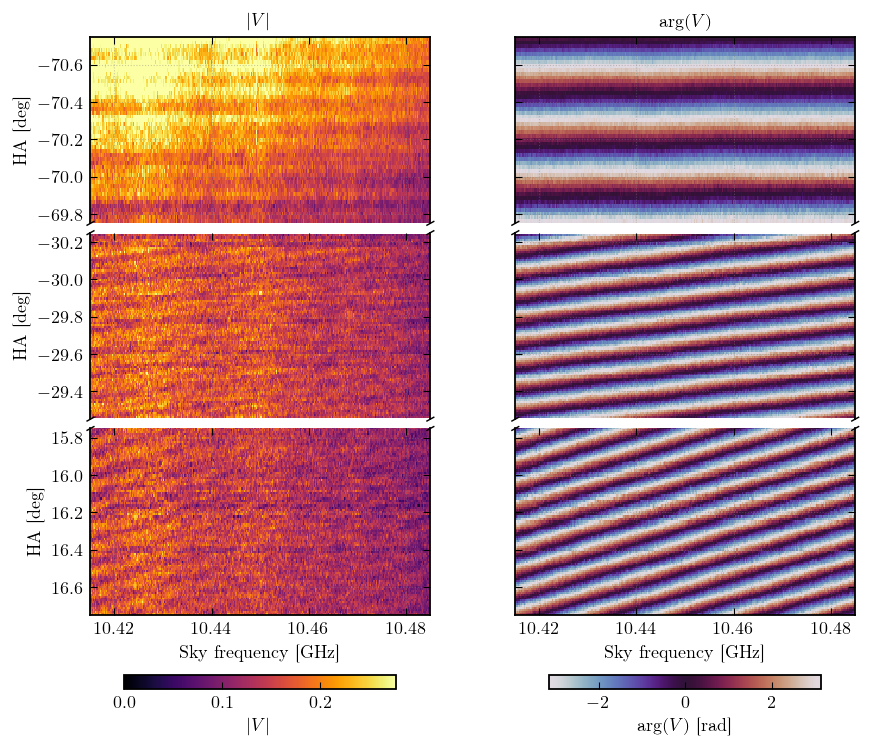

In [5]:
# --- Waterfall plot: |V| and arg(V) side by side with broken y-axis ---
ha_windows = [(-70.75, -69.75), (-30.25, -29.25), (15.75, 16.75)]
band_freqs = F_SKY_GHZ[band_mask]

# Collect data per window
panels = []
for ha_lo, ha_hi in ha_windows:
    ha_sel = (ha_deg_arr >= ha_lo) & (ha_deg_arr <= ha_hi)
    if ha_sel.sum() > 0:
        panels.append((ha_deg_arr[ha_sel], np.abs(corr_dc[ha_sel][:, band_mask])))
    else:
        panels.append(None)

vmax = np.nanpercentile(np.concatenate([p[1].ravel() for p in panels if p]), 98)
spans = [ha_hi - ha_lo for ha_lo, ha_hi in ha_windows]
n_panels = len(panels)

fig, all_axes = plt.subplots(n_panels, 2, figsize=(TEXTWIDTH_IN, 7.5), sharex="col",
                              gridspec_kw={"height_ratios": spans, "hspace": 0.05,
                                           "wspace": 0.25})

for row, (panel, (ha_lo, ha_hi)) in enumerate(zip(panels, ha_windows)):
    ax_amp = all_axes[row, 0]
    ax_ph = all_axes[row, 1]

    if panel is None:
        ax_amp.set_visible(False)
        ax_ph.set_visible(False)
        continue

    ha_w, amp_w = panel
    ha_sel = (ha_deg_arr >= ha_lo) & (ha_deg_arr <= ha_hi)
    phase_w = np.angle(corr_dc[ha_sel][:, band_mask])

    # Amplitude
    im_amp = ax_amp.pcolormesh(band_freqs, ha_w, amp_w,
                                cmap="inferno", shading="auto", vmin=0, vmax=vmax)
    ax_amp.set_ylim(ha_hi, ha_lo)
    ax_amp.set_ylabel("HA [deg]")

    # Phase
    im_ph = ax_ph.pcolormesh(band_freqs, ha_w, phase_w,
                              cmap="twilight", shading="auto", vmin=-np.pi, vmax=np.pi)
    ax_ph.set_ylim(ha_hi, ha_lo)
    ax_ph.set_yticklabels([])

    # Broken-axis styling for both columns
    for ax in [ax_amp, ax_ph]:
        if row < n_panels - 1:
            ax.spines["bottom"].set_visible(False)
            ax.tick_params(bottom=False)
        if row > 0:
            ax.spines["top"].set_visible(False)

        d = 0.5
        kw = dict(transform=ax.transAxes, color="k", clip_on=False, lw=0.8)
        if row > 0:
            ax.plot((-0.01, 0.01), (1 - d * 0.02, 1 + d * 0.02), **kw)
            ax.plot((0.99, 1.01), (1 - d * 0.02, 1 + d * 0.02), **kw)
        if row < n_panels - 1:
            ax.plot((-0.01, 0.01), (-d * 0.02, d * 0.02), **kw)
            ax.plot((0.99, 1.01), (-d * 0.02, d * 0.02), **kw)

all_axes[-1, 0].set_xlabel("Sky frequency [GHz]")
all_axes[-1, 1].set_xlabel("Sky frequency [GHz]")
all_axes[0, 0].set_title("$|V|$", fontsize=TICK_SIZE)
all_axes[0, 1].set_title("arg($V$)", fontsize=TICK_SIZE)

fig.colorbar(im_amp, ax=all_axes[:, 0], label="$|V|$", orientation="horizontal",
             shrink=0.8, pad=0.08, aspect=20)
fig.colorbar(im_ph, ax=all_axes[:, 1], label="arg($V$) [rad]", orientation="horizontal",
             shrink=0.8, pad=0.08, aspect=20)
fig.tight_layout()
plt.show()


## Adaptive window size vs hour angle

The window width (in captures) scales as $1/|\cos h|$, clamped to the configured range — the $1/|\cos h|$ scaling follows from the EW-baseline fringe-frequency expression $f_f \propto \cos h$ derived in §1.3 of the theory notebook ([TMS3] §4). This plot shows how the window adapts across the observation.

/tmp/ipykernel_971207/3013437217.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


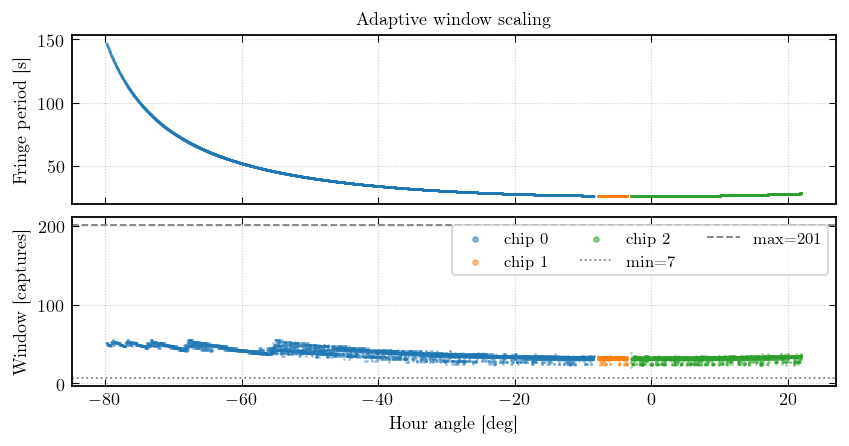

In [6]:
# --- Window size and local fringe period vs HA ---
local_period = fringe_period_s(ha_rad_arr, dec_rad_mean, NOMINAL_B_EW_M, 0.0, band_center_hz)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 3.5), sharex=True,
                         gridspec_kw={"hspace": 0.08})

# (a) Local fringe period
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], local_period[sl], s=0.2, color=CHIP_COLORS[ci],
                    alpha=0.5, rasterized=True)
axes[0].set_ylabel("Fringe period [s]")
axes[0].set_title("Adaptive window scaling", fontsize=TICK_SIZE)

# (b) Window size in captures
for ci, sl in enumerate(chip_slices):
    axes[1].scatter(ha_deg_arr[sl], window_caps_concat[sl], s=0.2, color=CHIP_COLORS[ci],
                    alpha=0.5, rasterized=True, label=f"chip {ci}")
axes[1].axhline(MIN_WINDOW_CAPS, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls=":", label=f"min={MIN_WINDOW_CAPS}")
axes[1].axhline(MAX_WINDOW_CAPS, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--", label=f"max={MAX_WINDOW_CAPS}")
axes[1].set_ylabel("Window [captures]")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].legend(fontsize=TICK_SIZE - 1, ncol=3, markerscale=6)

fig.tight_layout()
plt.show()

## DC-corrected visibility vs hour angle (representative channel)

Same four-panel layout as the raw data notebook, now after adaptive DC correction, shown at a single representative channel near the band centre. The real part should oscillate symmetrically about zero at all hour angles.

/tmp/ipykernel_971207/4287913067.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


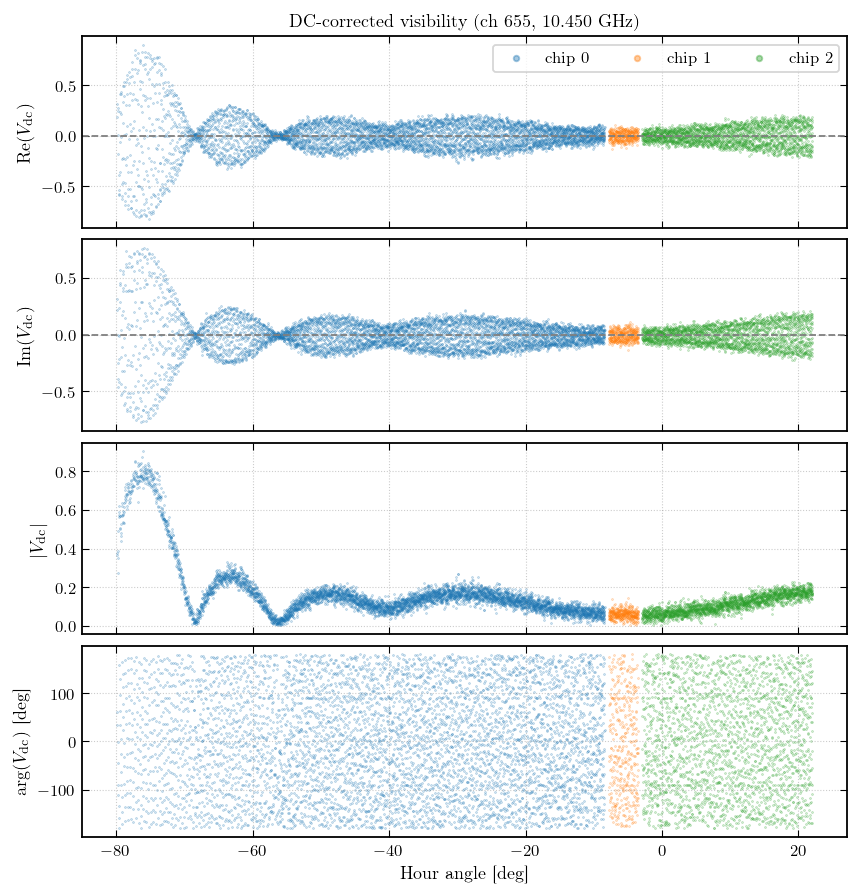

In [7]:
# --- DC-corrected visibility at representative channel: 4-panel plot ---
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
f_mid_ghz = F_SKY_GHZ[k_mid]
vis_dc_ch = corr_dc[:, k_mid]

dc_real  = vis_dc_ch.real
dc_imag  = vis_dc_ch.imag
dc_amp   = np.abs(vis_dc_ch)
dc_phase = np.angle(vis_dc_ch, deg=True)

fig, axes = plt.subplots(4, 1, figsize=(TEXTWIDTH_IN, 8.0), sharex=True,
                         gridspec_kw={"hspace": 0.06})

titles = [r"Re$(V_{\rm dc})$", r"Im$(V_{\rm dc})$", r"$|V_{\rm dc}|$", r"$\arg(V_{\rm dc})$ [deg]"]
data   = [dc_real, dc_imag, dc_amp, dc_phase]

for ax, title, y in zip(axes, titles, data):
    for ci, sl in enumerate(chip_slices):
        ax.scatter(ha_deg_arr[sl], y[sl], s=0.15, color=CHIP_COLORS[ci],
                   alpha=0.4, rasterized=True, label=f"chip {ci}" if ax is axes[0] else None)
    ax.set_ylabel(title, fontsize=TICK_SIZE)
    ax.tick_params(labelsize=TICK_SIZE - 1)
    if "Re" in title or "Im" in title:
        ax.axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")

axes[0].legend(fontsize=TICK_SIZE - 1, markerscale=8, ncol=N_chips, loc="upper right")
axes[0].set_title(f"DC-corrected visibility (ch {k_mid}, {f_mid_ghz:.3f} GHz)",
                  fontsize=TICK_SIZE)
axes[-1].set_xlabel("Hour angle [deg]")
fig.tight_layout()
plt.show()

## Fringe-frequency sanity check

Before the quantitative baseline fits of notebook 04, we verify that the
fringe signal is where we expect it. The local fringe frequency is (§1.3):

$$f_f(h) = \omega_\oplus \left[\frac{b_{\mathrm{ew}}}{\lambda}\cos\delta\,\cos h
  - \frac{b_{\mathrm{ns}}}{\lambda}\sin L\,\cos\delta\,\sin h\right].$$

At transit ($h=0$), $f_f \approx \omega_\oplus (b_{\mathrm{ew}}/\lambda)\cos\delta
\approx 0.038$ Hz (period $\sim 26$ s). Far from transit $f_f$ drops
as $\cos h$, stretching the fringes.

We compute a **short-time Fourier transform** (STFT) of a single
channel's Re($V_{\rm dc}$) and overlay the predicted $f_f(h)$. We also
show the time-averaged power spectrum to confirm the fringe peak sits
within the expected frequency range.

/tmp/ipykernel_971207/3441806185.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


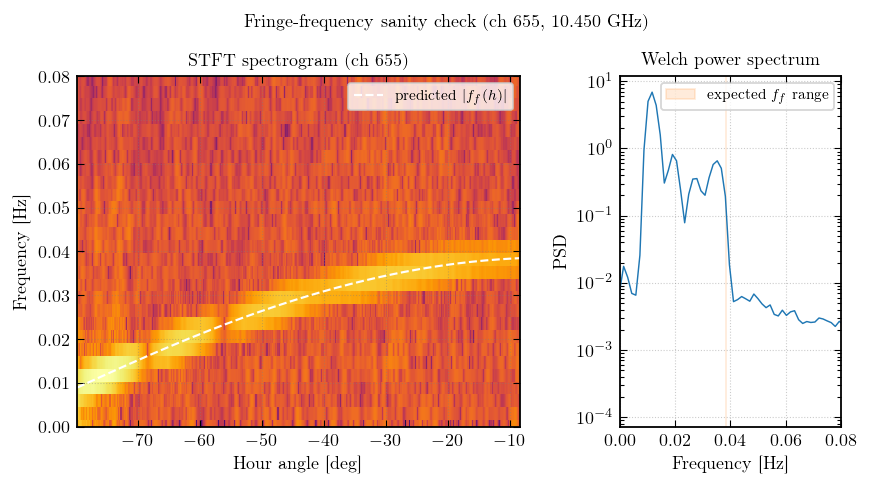

Expected f_f at transit: 38.56 mHz  (period 25.9 s)
Expected f_f range over chip 0: [38.45, 38.56] mHz


In [8]:
# --- Fringe-frequency sanity check: STFT spectrogram + power spectrum ---
from utils import fringe_frequency_hz, NOMINAL_B_NS_M, OMEGA_EARTH_RAD_S, C_LIGHT_MS

vis_ch = corr_dc[:, k_mid].real
valid = np.isfinite(vis_ch)

# Use chip 0 (longest continuous run) for the STFT
sl0 = chip_slices[0]
vis0 = vis_ch[sl0]
ha0 = ha_rad_arr[sl0]
t0 = unix_mid[sl0]
valid0 = np.isfinite(vis0)

# --- (a) STFT spectrogram ---
# Re-sample to uniform time grid for FFT
dt_median = np.median(np.diff(t0[valid0]))
t_uni = np.arange(t0[valid0][0], t0[valid0][-1], dt_median)
vis_uni = np.interp(t_uni, t0[valid0], vis0[valid0])
ha_uni = np.interp(t_uni, t0[valid0], ha0[valid0])

# STFT with Hann window
nperseg = 128
noverlap = nperseg - 16
from scipy.signal import stft as _stft
f_stft, t_stft, Zxx = _stft(vis_uni, fs=1.0/dt_median, nperseg=nperseg,
                              noverlap=noverlap, window='hann')
# Map STFT time indices back to HA
ha_stft = np.interp(t_stft + t_uni[0], t_uni, ha_uni)

# Predicted fringe frequency
ha_pred = np.linspace(ha0[valid0].min(), ha0[valid0].max(), 500)
ff_pred = np.abs(fringe_frequency_hz(ha_pred, dec_rad_mean,
                                      NOMINAL_B_EW_M, NOMINAL_B_NS_M,
                                      band_center_hz))

fig, (ax_stft, ax_psd) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 3.5),
                                        gridspec_kw={"width_ratios": [2, 1], "wspace": 0.3})

# Spectrogram
power = np.abs(Zxx)**2
ax_stft.pcolormesh(np.rad2deg(ha_stft), f_stft, 10*np.log10(power + 1e-30),
                    cmap="inferno", shading="auto")
ax_stft.plot(np.rad2deg(ha_pred), ff_pred, 'w--', lw=1.2,
              label=r"predicted $|f_f(h)|$")
ax_stft.set_ylim(0, 0.08)
ax_stft.set_xlabel("Hour angle [deg]")
ax_stft.set_ylabel("Frequency [Hz]")
ax_stft.set_title(f"STFT spectrogram (ch {k_mid})", fontsize=TICK_SIZE)
ax_stft.legend(fontsize=TICK_SIZE - 2, loc="upper right")

# --- (b) Time-averaged power spectrum ---
from scipy.signal import welch as _welch
f_psd, Pxx = _welch(vis_uni, fs=1.0/dt_median, nperseg=256, window='hann')

# Expected f_f range
ff_transit = abs(fringe_frequency_hz(0.0, dec_rad_mean,
                                      NOMINAL_B_EW_M, NOMINAL_B_NS_M, band_center_hz))
ff_min = abs(fringe_frequency_hz(ha0[valid0].max(), dec_rad_mean,
                                  NOMINAL_B_EW_M, NOMINAL_B_NS_M, band_center_hz))
ax_psd.semilogy(f_psd, Pxx, 'C0', lw=0.8)
ax_psd.axvspan(ff_min, ff_transit, alpha=0.15, color='C1',
                label=rf"expected $f_f$ range")
ax_psd.set_xlabel("Frequency [Hz]")
ax_psd.set_ylabel("PSD")
ax_psd.set_title("Welch power spectrum", fontsize=TICK_SIZE)
ax_psd.set_xlim(0, 0.08)
ax_psd.legend(fontsize=TICK_SIZE - 2)

fig.suptitle(f"Fringe-frequency sanity check (ch {k_mid}, {f_mid_ghz:.3f} GHz)",
             fontsize=TICK_SIZE, y=1.02)
fig.tight_layout()
plt.show()

print(f"Expected f_f at transit: {ff_transit*1e3:.2f} mHz  (period {1/ff_transit:.1f} s)")
print(f"Expected f_f range over chip 0: [{ff_min*1e3:.2f}, {ff_transit*1e3:.2f}] mHz")

## Phase slope vs frequency: geometric delay check

The phase of the complex visibility across frequency channels at a single
time encodes the geometric delay: $\phi(\nu) = 2\pi\nu\,\tau_g(h) + \phi_0$.
The slope $\mathrm{d}\phi/\mathrm{d}\nu = 2\pi\tau_g$ lets us recover the
delay directly. We fit a linear phase slope at three representative hour
angles and compare the inferred $\tau_g$ to the predicted value.

HA =  -60.00 deg:  tau_fit =   -4.930 ns,  tau_pred =  -42.430 ns,  diff = +37.500 ns
HA =  -30.00 deg:  tau_fit =  -24.601 ns,  tau_pred =  -22.892 ns,  diff = -1.709 ns
HA =   +5.00 deg:  tau_fit =  -54.499 ns,  tau_pred =   +7.187 ns,  diff = -61.686 ns


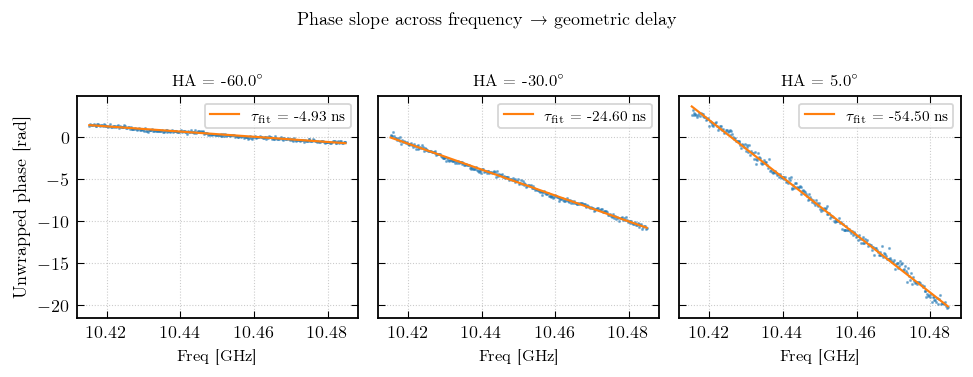

In [9]:
# --- Phase slope across frequency → geometric delay diagnostic ---
from utils import geometric_delay_s

# Pick three representative captures at different hour angles
ha_test_deg = [-60.0, -30.0, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(TEXTWIDTH_IN, 2.8), sharey=True)

for ax, ha_target in zip(axes, ha_test_deg):
    idx = np.argmin(np.abs(ha_deg_arr - ha_target))
    vis_spec = corr_dc[idx, :]
    phase_spec = np.angle(vis_spec)
    ha_actual = ha_rad_arr[idx]
    dec_actual = np.deg2rad(sun_dec[idx]) if np.isfinite(sun_dec[idx]) else dec_rad_mean

    # Unwrap phase across the analysis band
    freqs = F_SKY_HZ[band_mask]
    ph = phase_spec[band_mask]
    good = np.isfinite(ph)
    if good.sum() < 10:
        ax.text(0.5, 0.5, "insufficient data", transform=ax.transAxes, ha='center')
        continue

    ph_unwrap = np.unwrap(ph[good])
    f_good = freqs[good]

    # Linear fit: phase = 2*pi*tau_g * freq + offset
    coeffs = np.polyfit(f_good, ph_unwrap, 1)
    tau_fit = coeffs[0] / (2.0 * np.pi)  # seconds
    tau_pred = geometric_delay_s(ha_actual, dec_actual, NOMINAL_B_EW_M, NOMINAL_B_NS_M)

    ax.scatter(f_good / 1e9, ph_unwrap, s=0.5, alpha=0.5, color='C0', rasterized=True)
    ax.plot(f_good / 1e9, np.polyval(coeffs, f_good), 'C1', lw=1.2,
            label=rf"$\tau_{{\rm fit}}$ = {tau_fit*1e9:.2f} ns")
    ax.set_xlabel("Freq [GHz]", fontsize=TICK_SIZE - 1)
    ax.set_title(rf"HA = {ha_deg_arr[idx]:.1f}$^\circ$", fontsize=TICK_SIZE - 1)
    ax.legend(fontsize=TICK_SIZE - 2, loc="best")

    print(f"HA = {ha_deg_arr[idx]:+7.2f} deg:  "
          f"tau_fit = {tau_fit*1e9:+8.3f} ns,  "
          f"tau_pred = {tau_pred*1e9:+8.3f} ns,  "
          f"diff = {(tau_fit - tau_pred)*1e9:+.3f} ns")

axes[0].set_ylabel("Unwrapped phase [rad]")
fig.suptitle("Phase slope across frequency → geometric delay", fontsize=TICK_SIZE, y=1.02)
fig.tight_layout()
plt.show()

## Before vs after: raw and corrected Re(V) side by side

Direct comparison of the real part before and after DC correction. The bottom panel shows the subtracted pedestal, which should track the slow elevation-dependent system temperature variation.

/tmp/ipykernel_971207/3544114787.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


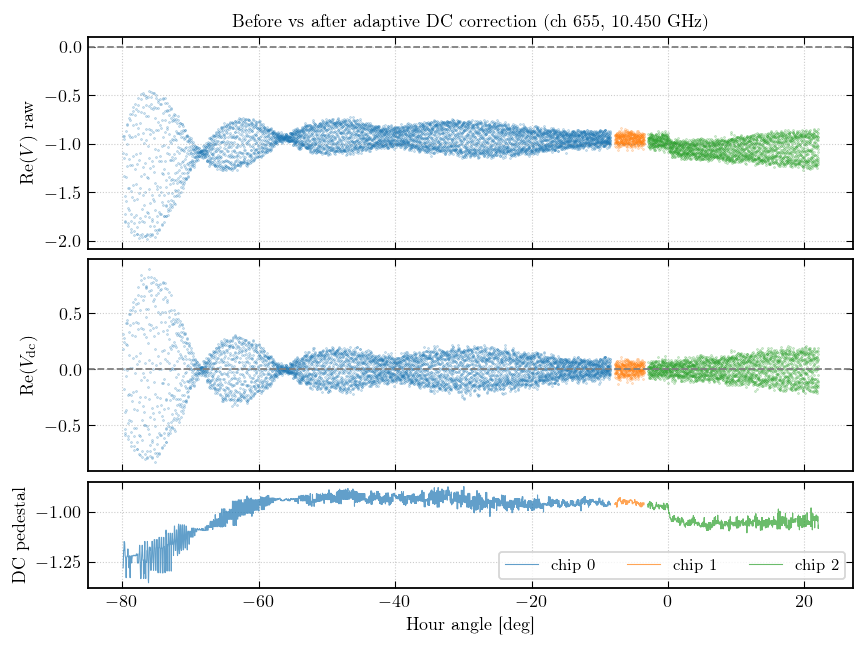

In [10]:
# --- Before / after comparison (representative channel) ---
raw_band_real = corr_raw[:, k_mid].real
offset_band   = np.vstack(real_offset_chips)[:, k_mid]

fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 5.5), sharex=True,
                         gridspec_kw={"hspace": 0.06, "height_ratios": [2, 2, 1]})

# (a) Raw Re(V)
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], raw_band_real[sl], s=0.15, color=CHIP_COLORS[ci],
                    alpha=0.4, rasterized=True)
axes[0].axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")
axes[0].set_ylabel(r"Re$(V)$ raw")
axes[0].set_title(f"Before vs after adaptive DC correction (ch {k_mid}, {f_mid_ghz:.3f} GHz)",
                  fontsize=TICK_SIZE)

# (b) Corrected Re(V)
for ci, sl in enumerate(chip_slices):
    axes[1].scatter(ha_deg_arr[sl], dc_real[sl], s=0.15, color=CHIP_COLORS[ci],
                    alpha=0.4, rasterized=True)
axes[1].axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")
axes[1].set_ylabel(r"Re$(V_{\rm dc})$")

# (c) Subtracted pedestal
for ci, sl in enumerate(chip_slices):
    axes[2].plot(ha_deg_arr[sl], offset_band[sl], lw=LW_FINE, color=CHIP_COLORS[ci],
                 alpha=0.7, label=f"chip {ci}")
axes[2].set_ylabel("DC pedestal")
axes[2].set_xlabel("Hour angle [deg]")
axes[2].legend(fontsize=TICK_SIZE - 1, ncol=N_chips)

fig.tight_layout()
plt.show()

## Imaginary-part DC diagnostic

The adaptive rolling-median correction subtracts only from the real part
of $V$. If the correlator introduces a DC offset on the imaginary part
(e.g., from quadrature imbalance), it would go uncorrected. We check this
by computing the median Im($V$) per chip in the analysis band.

In [11]:
# --- Imaginary-part DC diagnostic ---
corr_band_dc = corr_dc[:, band_mask]
print("Imaginary-part DC check (median Im(V) per chip in analysis band):")
print("-" * 55)
for ci, sl in enumerate(chip_slices):
    im_median = np.nanmedian(corr_band_dc[sl].imag)
    re_median_raw = np.nanmedian(corr_raw[sl][:, band_mask].real)
    im_frac = abs(im_median) / max(abs(re_median_raw), 1e-10)
    status = "OK" if im_frac < 0.05 else "CHECK"
    print(f"  Chip {ci}: median Im(V) = {im_median:+.4f}  "
          f"(|Im/Re_raw| = {im_frac:.3f})  {status}")
print()
print("If |Im/Re_raw| << 1 for all chips, the imaginary-part DC offset")
print("is negligible and the real-only correction is sufficient.")

Imaginary-part DC check (median Im(V) per chip in analysis band):
-------------------------------------------------------
  Chip 0: median Im(V) = +0.0026  (|Im/Re_raw| = 0.003)  OK
  Chip 1: median Im(V) = +0.0026  (|Im/Re_raw| = 0.003)  OK
  Chip 2: median Im(V) = +0.0028  (|Im/Re_raw| = 0.003)  OK

If |Im/Re_raw| << 1 for all chips, the imaginary-part DC offset
is negligible and the real-only correction is sufficient.


## Synthetic injection test: how much fringe power does the DC step actually subtract?

To quantify the bias the adaptive median introduces, we generate a clean
synthetic fringe at the *measured* hour angles, with no noise and no
pedestal, run it through the same `adaptive_real_dc_correction` we use on
the real data, and compare input vs output. The ratio
`std(after) / std(before)` is the **fringe attenuation factor**: a value
of 1.0 means no leakage; a value of 0.99 means the rolling median removes
1% of the real fringe along with the DC.

We also inject a known DC pedestal (a smooth function of hour angle) to
confirm the corrector tracks and removes it.

In [12]:
# --- Synthetic injection test: measure the amplitude bias alpha of the DC corrector ---
#
# We inject a *realistic* Bessel-modulated solar fringe (not a constant-
# amplitude sinusoid) plus a smooth elevation-like DC pedestal, run it
# through the same adaptive corrector, and measure how much the corrector
# distorts the recovered fringe amplitude.
from utils import (
    point_source_visibility, FringeModelParams,
    SolarDiskParams, solar_visibility,
    NOMINAL_B_NS_M,
)

params_inj = FringeModelParams(
    b_ew=NOMINAL_B_EW_M,
    b_ns=NOMINAL_B_NS_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    amplitude=1.0,
    phase_offset=0.0,
)
# Use the nominal solar radius (~15.8 arcmin) for a realistic Bessel envelope
_R_NOM_RAD = np.deg2rad(31.6 / 2.0 / 60.0)
disk_inj = SolarDiskParams(angular_radius_rad=_R_NOM_RAD)

# Build a Bessel-modulated complex fringe at every measured HA, then add a
# smooth elevation-like pedestal to the real part ONLY.
v_clean = solar_visibility(ha_rad_arr, params_inj, disk_inj)
pedestal_true = 0.3 * np.cos(ha_rad_arr) + 0.05 * np.cos(2 * ha_rad_arr) + 0.5
v_input = v_clean.copy()
v_input.real += pedestal_true

# Reshape to (N_cap, 1) so the corrector can run on it as a single-channel
# "data set", and run it with the exact same parameters as on the real data.
v_input_2d = v_input[:, None].astype(complex)
inj_result = adaptive_real_dc_correction(
    corr_chips=[v_input_2d[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=np.array([], dtype=int),
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=N_PERIODS,
    min_window_caps=MIN_WINDOW_CAPS,
    max_window_caps=MAX_WINDOW_CAPS,
)
v_corrected = inj_result.corr_dc[:, 0]

# ---- Multiplicative amplitude recovery factor (alpha) via projection ----
#
# Define alpha by least-squares projection: the ratio of inner products
#
#     alpha = < v_corrected.real,  v_clean.real > / < v_clean.real, v_clean.real >.
#
# With a Bessel-modulated fringe (realistic), the rolling median tracks
# the pedestal better near nulls (low fringe amplitude) and near transit
# (short fringe period = more cycles per window), so the bias should be
# smaller than for a constant-amplitude sinusoid.
mask_finite = np.isfinite(v_corrected.real) & np.isfinite(v_clean.real)
num = float(np.dot(v_corrected.real[mask_finite], v_clean.real[mask_finite]))
den = float(np.dot(v_clean.real[mask_finite], v_clean.real[mask_finite]))
alpha_dc = num / den

# Residual pedestal: what the corrector FAILED to remove, compared to the
# true pedestal (ideally zero).
pedestal_removed = v_input.real - v_corrected.real
residual_pedestal = pedestal_removed - pedestal_true
residual_pedestal_std = float(np.nanstd(residual_pedestal))

# Additional sanity check: residual RMS on top of alpha*v_clean
residual_vs_projection = (
    v_corrected.real[mask_finite] - alpha_dc * v_clean.real[mask_finite]
)
residual_std = float(np.std(residual_vs_projection))

# ---- Pass/fail criteria --------------------------------------------------
PASS_ALPHA_TOL = 0.03          # |alpha - 1| must be < 3%
PASS_PEDESTAL_TOL = 0.03       # residual pedestal std < 3% of injected amplitude
injected_amp = float(np.ptp(pedestal_true))
alpha_ok    = abs(alpha_dc - 1.0) < PASS_ALPHA_TOL
pedestal_ok = residual_pedestal_std < PASS_PEDESTAL_TOL * injected_amp
status = "PASS" if (alpha_ok and pedestal_ok) else "FAIL"

print("Synthetic injection test for the adaptive DC corrector")
print("(Bessel-modulated fringe, R_sun ~ 15.8 arcmin)")
print("-" * 62)
print(f"  alpha (projection)    = {alpha_dc:.4f}  "
      f"({(alpha_dc - 1.0) * 100:+.2f}% from unity)")
if alpha_dc > 1.0:
    print(f"  -> residual DC pedestal leaks into the corrected fringe,")
    print(f"     *inflating* the recovered amplitude by "
          f"{(alpha_dc - 1.0) * 100:.2f}%")
elif alpha_dc < 1.0:
    print(f"  -> the rolling median leaked some fringe into the pedestal,")
    print(f"     *attenuating* the recovered amplitude by "
          f"{(1.0 - alpha_dc) * 100:.2f}%")
else:
    print("  -> no multiplicative amplitude bias")
print()
print(f"  residual pedestal std = {residual_pedestal_std:.4f}")
print(f"  residual-on-projection std = {residual_std:.4f}")
print(f"  injected pedestal amp = {injected_amp:.4f}")
print()
print(f"  pass/fail tolerances: |alpha-1|<{PASS_ALPHA_TOL}, "
      f"residual<{PASS_PEDESTAL_TOL}*amp")
print(f"  alpha criterion:    {'ok' if alpha_ok else 'FAIL'}")
print(f"  pedestal criterion: {'ok' if pedestal_ok else 'FAIL'}")
print(f"  overall:            {status}")
print()
print("The value of alpha is exported as DC_CORRECTION_ALPHA for downstream use")
print("in notebook 05's diameter error budget (fractional systematic on the")
print("fringe envelope amplitude).")

# Export: this variable is picked up by the nb 05 validation cell, and the
# value is also persisted to a sidecar file so later runs can recover it.
DC_CORRECTION_ALPHA = float(alpha_dc)

import pickle as _pkl
sidecar = Path("_dc_correction_alpha.pkl")
with open(sidecar, "wb") as _f:
    _pkl.dump({
        "alpha": DC_CORRECTION_ALPHA,
        "residual_pedestal_std": residual_pedestal_std,
        "residual_vs_projection_std": residual_std,
        "pass": bool(alpha_ok and pedestal_ok),
        "n_periods": N_PERIODS,
        "min_window_caps": MIN_WINDOW_CAPS,
        "max_window_caps": MAX_WINDOW_CAPS,
    }, _f)
print(f"Wrote sidecar: {sidecar.resolve()}")

Synthetic injection test for the adaptive DC corrector
(Bessel-modulated fringe, R_sun ~ 15.8 arcmin)
--------------------------------------------------------------
  alpha (projection)    = 1.0967  (+9.67% from unity)
  -> residual DC pedestal leaks into the corrected fringe,
     *inflating* the recovered amplitude by 9.67%

  residual pedestal std = 0.0040
  residual-on-projection std = 0.0032
  injected pedestal amp = 0.3441

  pass/fail tolerances: |alpha-1|<0.03, residual<0.03*amp
  alpha criterion:    FAIL
  pedestal criterion: ok
  overall:            FAIL

The value of alpha is exported as DC_CORRECTION_ALPHA for downstream use
in notebook 05's diameter error budget (fractional systematic on the
fringe envelope amplitude).
Wrote sidecar: /home/ikaros/projects/ay-121/labs/03/notebooks/_dc_correction_alpha.pkl
